In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

pandas 라이브러리의 read_excel() 메소드로 엑셀 파일을 읽으려면 `pandas`, `openpyxl` 라이브러리가 필수적으로 요구되므로 `pandas`, `openpyxl` 설치하고 import 한다.  
!pip install openpyxl

In [2]:
import openpyxl

# 분석 대상 데이터

국회미래연구원에서 고려대학교와 공동으로 연구·구축하여 2020년에 오픈한 대한민국 행복지도 공식 사이트(`http://happykorea.re.kr/`)는 현재 사이트가 `폐쇄된 상태`이다.  
시군구별 행복역량지수, 삶의 만족도 등을 시각화하여 제공했던 이 프로젝트는 상시 유지되는 대국민 포털 서비스라기보다는 연구 결과 발표 및 시범 공개 성격이 강했다. 이에 따라 연구 종료 및 도메인 유지 계약 만료 등으로 인해 기존 독립 `웹사이트의 접속이 중단`되었다.

① `대한민국행복지도_삶의만족도.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 자신의 삶(과거와 현재)에 만족하는 정도  

② `대한민국행복지도_건강.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 주관적 건강수준 인지율  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 정신건강증진기관 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 의료기관 종사자의 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 건강생활 실천률  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 의료기관 병상 수  

③ `대한민국행복지도_안전.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 사회안전에 대한 인식  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 cctv 대수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 응급의료기관 및 응급실 운영기관 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 단위면적당 지역경찰관서 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 지역안전등급 현황 중 '교통사고 및 화재'  

④ `대한민국행복지도_환경.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 환경체감도  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 1일 산업폐수 방류량  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 도시지역 중 '녹지지역 비율'  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 미세먼지(PM2.5)  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 주민 1인당 생활폐기물 배출량  

⑤ `대한민국행복지도_경제.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 1인당 지역내총생산(GRDP)  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 사업체 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 종사자 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 국민기초생활보장 수급자 비율  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 종사자 천 명당 영세자영업자 수  

⑥ `대한민국행복지도_교육.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 교원 1인당 학생 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 영유아 천 명당 보육시설 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 학교 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 사설학원 수  

⑦ `대한민국행복지도_관계및사회참여.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 자살률  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 1인가구(독거노인 제외) 비율  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 독거노인가구 비율  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 사회적기업 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 가족관계 만족도  

⑧ `대한민국행복지도_여가.xlsx`  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 여가활용 만족도  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 노인 천 명당 노인여가복지시설 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 도서관 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 십만 명당 문화기반 시설 수  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 인구 천 명당 체육관련 여가시설 수  

======================================================================================================================

## 관련 데이터 및 유사 정보를 확인할 수 있는 대안

① 국회미래연구원 공식 홈페이지(`nafi.re.kr`)  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 기존 행복지도 관련 연구 보고서, '한국인의 행복 조사 심층 분석', '청년의 행복 불평등' 등 후속 자료를 PDF 형태로 열람할 수 있다.  
② 통계청 국가지표체계 지표누리(`index.go.kr`)  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 국민의 주관적 웰빙, 삶의 만족도, 건강, 안전, 여가 등 삶의 질과 관련된 공식 국가 통계 지표들을 상세하게 조회할 수 있다.  
③ 대한민국 국가지도집(`nationalatlas.ngii.go.kr`)  
&nbsp;&nbsp;&nbsp;&nbsp;▶ 국토지리정보원에서 발간하는 국가지도집 내 '삶의 질 지수 및 행복지수' 섹션에서 관련 통계 지도와 시각화 자료를 참고할 수 있다.

## pandas를 사용해서 엑셀 파일 읽어오기

In [3]:
# 대한민국행복지도_삶의만족도.xlsx 엑셀 파일 읽어오기
happy_life = pd.read_excel('./data/대한민국행복지도_삶의만족도.xlsx')
happy_life.head()

,No,시도,구군,삶의 만족도
0,1,서울특별시,종로구,0.4437
1,2,서울특별시,중구,0.4976
2,3,서울특별시,용산구,0.6161
3,4,서울특별시,성동구,0.4729
4,5,서울특별시,광진구,0.4041


In [4]:
# 대한민국행복지도_건강.xlsx 엑셀 파일 읽어오기
happy_health = pd.read_excel('./data/대한민국행복지도_건강.xlsx')
happy_health.head()

,No,시도,구군,평균,주관적 건강수준 인지율,인구 십만명당 정신건강증진기관 수,인구 천명당 의료기관 종사 의사수,건강생활실천율,인구 천명당 의료기관병상수
0,1,서울특별시,종로구,0.9220,0.8424,0.6914,1.0000,0.9697,0.7616
1,2,서울특별시,중구,0.6742,0.5772,0.4106,0.9995,0.9669,0.4043
2,3,서울특별시,용산구,0.5898,0.9819,0.3353,0.6046,0.9844,0.1433
3,4,서울특별시,성동구,0.4794,0.5465,0.3321,0.5783,0.9776,0.2111
4,5,서울특별시,광진구,0.6373,0.8534,0.7393,0.6352,0.8022,0.1936


In [5]:
# 대한민국행복지도_경제.xlsx 엑셀 파일 읽어오기
happy_econo = pd.read_excel('./data/대한민국행복지도_경제.xlsx')
happy_econo.head()

,No,시도,구군,평균,1인당 지역내총생산(GRDP),인구 천명당 사업체수,인구 천명당 종사자수,국민기초생활보장 수급자비율 a),종사자 천명당 영세자영업자 수 a)
0,1,서울특별시,종로구,1.0000,1.0000,1.0000,1.0000,0.7564,0.9037
1,2,서울특별시,중구,0.9806,1.0000,1.0000,1.0000,0.6718,0.9177
2,3,서울특별시,용산구,0.6915,0.6334,0.5493,0.7282,0.7910,0.8341
3,4,서울특별시,성동구,0.6533,0.5132,0.5368,0.6849,0.8243,0.8377
4,5,서울특별시,광진구,0.4445,0.2906,0.3424,0.3870,0.8681,0.7480


In [6]:
# 대한민국행복지도_관계및사회참여.xlsx 엑셀 파일 읽어오기
happy_relation = pd.read_excel('./data/대한민국행복지도_관계및사회참여.xlsx')
happy_relation.head()

,No,시도,구군,평균,인구 십만명당 자살률 a),1인가구(독거노인 제외) 비율 a),독거노인가구 비율 a),인구 십만명당 사회적기업수,가족관계 만족도 b)
0,1,서울특별시,종로구,0.7425,0.8318,0.0057,0.7593,0.9981,0.5949
1,2,서울특별시,중구,0.4608,0.5462,0.0107,0.7254,1.0000,0.2329
2,3,서울특별시,용산구,0.4317,0.7288,0.0211,0.7754,0.7194,0.2009
3,4,서울특별시,성동구,0.4182,0.7288,0.0791,0.8332,0.6783,0.0937
4,5,서울특별시,광진구,0.3519,0.9434,0.0051,0.8541,0.2461,0.2058


In [7]:
# 대한민국행복지도_교육.xlsx 엑셀 파일 읽어오기
happy_edu = pd.read_excel('./data/대한민국행복지도_교육.xlsx')
happy_edu.head()

,No,시도,구군,평균,교원 1인당 학생수,영유아 천명당 보육시설 수,인구 십만명당 학교수,인구 천명당 사설학원수
0,1,서울특별시,종로구,0.6839,0.8505,0.6248,0.2249,0.8126
1,2,서울특별시,중구,0.5013,0.8729,0.4147,0.2294,0.2944
2,3,서울특별시,용산구,0.2679,0.6479,0.3804,0.1281,0.1629
3,4,서울특별시,성동구,0.2464,0.7661,0.2270,0.1308,0.3366
4,5,서울특별시,광진구,0.4879,0.9309,0.4263,0.1278,0.4607


In [8]:
# 대한민국행복지도_안전.xlsx 엑셀 파일 읽어오기
happy_safe = pd.read_excel('./data/대한민국행복지도_안전.xlsx')
happy_safe.head()

,No,시도,구군,평균,사회안전에 대한 인식 b),인구 천명당 cctv 대수 b),인구 십만명당 응급의료기관 및 응급실 운영기관수,단위면적당 지역경찰관서 수,지역안전등급 현황 중 '교통사고 및 화재' a)
0,1,서울특별시,종로구,0.7470,0.9965,0.4796,0.7498,0.9998,0.0162
1,2,서울특별시,중구,0.9320,0.9707,0.8214,0.6938,1.0000,0.3014
2,3,서울특별시,용산구,0.5537,0.6641,0.4311,0.1768,0.8923,0.5075
3,4,서울특별시,성동구,0.5347,0.7452,0.4330,0.1562,0.9800,0.3014
4,5,서울특별시,광진구,0.6072,0.7179,0.2196,0.2019,0.9785,0.7117


In [9]:
# 대한민국행복지도_여가.xlsx 엑셀 파일 읽어오기
happy_leisure = pd.read_excel('./data/대한민국행복지도_여가.xlsx')
happy_leisure.head()

,No,시도,구군,평균,여가활용 만족도 b),노인 천명당 노인여가복지시설수,인구 십만명당 도서관수,인구 십만명당 문화기반시설수,인구 천명당 체육관련 여가시설수
0,1,서울특별시,종로구,0.6331,0.8409,0.1573,0.4523,0.9997,0.5559
1,2,서울특별시,중구,0.6691,0.6224,0.1467,0.5369,0.8441,0.9886
2,3,서울특별시,용산구,0.2817,0.6381,0.1628,0.2453,0.3715,0.2934
3,4,서울특별시,성동구,0.3257,0.5657,0.1859,0.3590,0.2768,0.4859
4,5,서울특별시,광진구,0.3313,0.6740,0.1443,0.2333,0.2058,0.6365


In [10]:
# 대한민국행복지도_환경.xlsx 엑셀 파일 읽어오기
happy_environ = pd.read_excel('./data/대한민국행복지도_환경.xlsx')
happy_environ.head()

,No,시도,구군,평균,환경체감도 b),인구 천명당 1일 산업폐수 방류량 a),도시지역 중 '녹지지역 비율',미세먼지(PM2.5) a) b),주민 1인당 생활폐기물배출량 a)
0,1,서울특별시,종로구,0.4637,0.4658,0.7223,0.2012,0.7704,0.0006
1,2,서울특별시,중구,0.2865,0.1077,0.6957,0.0013,0.6617,0.0000
2,3,서울특별시,용산구,0.5030,0.3142,0.7185,0.1349,0.6895,0.4571
3,4,서울특별시,성동구,0.4196,0.1480,0.6868,0.0347,0.3757,0.7426
4,5,서울특별시,광진구,0.4992,0.1229,0.6940,0.0574,0.7235,0.7016


## 데이터 가공하기

'시도' 데이터를 추출한다.  
데이터프레임에서 '시도' 지역별 고유값(중복을 제거한 목록)을 추출한 뒤, 새로운 데이터프레임을 생성한다.

In [11]:
# unique() 메소드는 선택한 열에 포함된 값들 중에서 중복을 제거하고 유일한 값들만 추출한다.
# 단순히 중복을 제거하려면 set()을 사용해도 되지만 set()을 사용하면 데이터의 순서가 변경되므로 데이터의 순서를 유지하기 위해 unique() 메소드를 사용했다.
city = list(happy_life.시도.unique())
happy_merge = pd.DataFrame({'시도': city})
happy_merge

,시도
0,서울특별시
1,부산광역시
2,대구광역시
3,인천광역시
4,광주광역시
5,대전광역시
6,울산광역시
7,세종특별자치시
8,경기도
9,강원도


기준 데이터프레임(happy_merge)에 다른 데이터프레임의 데이터를 합치는(병합하는) 데이터 전처리를 실행한다.

In [12]:
# '삶의만족도' 데이터 병합
# happy_life 데이터프레임의 '삶의 만족도' 열을 '시도' 열을 기준으로 그룹화해서 '삶의 만족도' 열의 평균값을 계산한다.
life = happy_life['삶의 만족도'].groupby(by=happy_life['시도']).mean()
# merge() 메소드는 판다스에서 두 개의 데이터프레임을 하나로 합칠 때 사용한다.
# on 속성은 속성값으로 지정한 열('시도')을 두 데이터프레임을 합칠 때 기준이되는 공통 열로 지정한다.
# 병합 후 데이터 순서는 merge() 메소드의 첫 번째 인수로 지정한(happy_merge) 데이터프레임이 기준으로 합쳐진다.
# happy_merge 데이터프레임에 병합되는 시리즈(life)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, life.rename('삶의만족도'), on='시도')
happy_merge

,시도,삶의만족도
0,서울특별시,0.490972
1,부산광역시,0.362081
2,대구광역시,0.363988
3,인천광역시,0.411480
4,광주광역시,0.484480
5,대전광역시,0.407580
6,울산광역시,0.471980
7,세종특별자치시,0.907700
8,경기도,0.426023
9,강원도,0.619506


In [13]:
# '건강' 데이터 병합
# happy_health 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
health = happy_health['평균'].groupby(by=happy_health['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(health)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, health.rename('건강'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강
0,서울특별시,0.490972,0.569532
1,부산광역시,0.362081,0.511906
2,대구광역시,0.363988,0.482325
3,인천광역시,0.411480,0.339620
4,광주광역시,0.484480,0.632300


In [14]:
# '안전' 데이터 병합
# happy_safe 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
safe = happy_safe['평균'].groupby(by=happy_safe['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(safe)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, safe.rename('안전'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강,안전
0,서울특별시,0.490972,0.569532,0.552256
1,부산광역시,0.362081,0.511906,0.404875
2,대구광역시,0.363988,0.482325,0.358429
3,인천광역시,0.411480,0.339620,0.421020
4,광주광역시,0.484480,0.632300,0.266440


In [15]:
# '환경' 데이터 병합
# happy_environ 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
environ = happy_environ['평균'].groupby(by=happy_environ['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(environ)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, environ.rename('환경'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강,안전,환경
0,서울특별시,0.490972,0.569532,0.552256,0.470712
1,부산광역시,0.362081,0.511906,0.404875,0.448719
2,대구광역시,0.363988,0.482325,0.358429,0.552500
3,인천광역시,0.411480,0.339620,0.421020,0.515020
4,광주광역시,0.484480,0.632300,0.266440,0.607480


In [16]:
# '경제' 데이터 병합
# happy_econo 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
econo = happy_econo['평균'].groupby(by=happy_econo['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(econo)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, econo.rename('경제'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강,안전,환경,경제
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380


In [17]:
# '교육' 데이터 병합
# happy_edu 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
edu = happy_edu['평균'].groupby(by=happy_edu['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(edu)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, edu.rename('교육'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강,안전,환경,경제,교육
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680


In [18]:
# '관계및사회참여' 데이터 병합
# happy_relation 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
relation = happy_relation['평균'].groupby(by=happy_relation['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(relation)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, relation.rename('관계및사회참여'), on='시도')
happy_merge.head()

,시도,삶의만족도,건강,안전,환경,경제,교육,관계및사회참여
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412,0.390656
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594,0.294719
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838,0.407486
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920,0.504920
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680,0.637800


In [19]:
# '여가' 데이터 병합
# happy_leisure 데이터프레임의 '평균' 열을 '시도' 열을 기준으로 그룹화해서 '평균' 열의 평균값을 계산한다.
leisure = happy_leisure['평균'].groupby(by=happy_leisure['시도']).mean()
# happy_merge 데이터프레임에 병합되는 시리즈(leisure)에 rename() 메소드로 열 이름을 수정한다.
happy_merge = pd.merge(happy_merge, leisure.rename('여가'), on='시도')
happy_merge

,시도,삶의만족도,건강,안전,환경,경제,교육,관계및사회참여,여가
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412,0.390656,0.286732
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594,0.294719,0.153587
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838,0.407486,0.234925
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920,0.504920,0.244590
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680,0.637800,0.454980
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260,0.840780,0.510820,0.347960
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580,0.763240,0.676440,0.418420
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900,0.587000,0.673700,0.447800
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926,0.668619,0.601532,0.377561
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861,0.488533,0.563122,0.632750


데이터 결손 확인

In [20]:
happy_merge.isnull().sum()

시도         0
삶의만족도      0
건강         0
안전         0
환경         0
경제         0
교육         0
관계및사회참여    0
여가         0
dtype: int64

데이터 타입 확인

In [21]:
happy_merge.dtypes

시도             str
삶의만족도      float64
건강         float64
안전         float64
환경         float64
경제         float64
교육         float64
관계및사회참여    float64
여가         float64
dtype: object

In [22]:
happy_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시도       17 non-null     str    
 1   삶의만족도    17 non-null     float64
 2   건강       17 non-null     float64
 3   안전       17 non-null     float64
 4   환경       17 non-null     float64
 5   경제       17 non-null     float64
 6   교육       17 non-null     float64
 7   관계및사회참여  17 non-null     float64
 8   여가       17 non-null     float64
dtypes: float64(8), str(1)
memory usage: 1.3 KB


데이터 집계 내용 확인

In [23]:
happy_merge.describe()

,삶의만족도,건강,안전,환경,경제,교육,관계및사회참여,여가
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,0.518189,0.409401,0.420882,0.579406,0.407635,0.578653,0.497632,0.464910
std,0.138257,0.127636,0.123557,0.097299,0.111265,0.125408,0.114394,0.176206
min,0.362081,0.232000,0.157800,0.393440,0.196543,0.399412,0.294719,0.153587
25%,0.411480,0.329506,0.358429,0.515020,0.386861,0.488533,0.402183,0.347960
50%,0.490972,0.401064,0.446100,0.582380,0.410820,0.587000,0.487464,0.454980
75%,0.553100,0.482325,0.484835,0.652400,0.468926,0.648047,0.601532,0.632750
max,0.907700,0.663580,0.573155,0.735600,0.642580,0.840780,0.676440,0.702891


행복지수 요소별 평균 확인

happy_merge 데이터프레임에 mean() 메소드를 실행하면 '시도' 열이 str 타입이므로 에러가 발생된다.

In [24]:
# str 타입이 아닌 열만 지정해서 평균을 계산한다.
# happy_merge['삶의만족도'].mean()
# happy_merge[['삶의만족도', '건강', '안전', '환경', '경제', '교육', '관계및사회참여', '여가']].mean()
# column = list(happy_merge.columns)
# column.remove('시도')
# happy_merge[column].mean()

# numeric_only 속성의 기본값은 False이고 모든 열을 대상으로 계산하며 True로 지정하면 숫자 열만을 대상으로 계산한다.
# axis 속성의 기본값은 0이고 열 방향으로 계산하고 1로 지정하면 행 방향으로 계산한다.
happy_merge.mean(numeric_only=True, axis=0) # 열 방향 평균

삶의만족도      0.518189
건강         0.409401
안전         0.420882
환경         0.579406
경제         0.407635
교육         0.578653
관계및사회참여    0.497632
여가         0.464910
dtype: float64

In [25]:
# 시도별 평균을 계산한다.
happy_merge.mean(numeric_only=True, axis=1) # 행 방향 평균

0     0.461637
1     0.389815
2     0.422433
3     0.418799
4     0.520068
5     0.497017
6     0.532900
7     0.521288
8     0.472481
9     0.526015
10    0.500400
11    0.508128
12    0.488729
13    0.500111
14    0.436254
15    0.482856
16    0.559075
dtype: float64

`set_index()` 메소드는 데이터프레임의 `기존 열을 행을 식별하는 인덱스로 지정`한다. 데이터의 구조를 재조정하고 특정 기준으로 데이터를 조회거나 그룹화할 때 사용한다.

In [29]:
happy_merge.set_index('시도').mean(numeric_only=True, axis=1)

시도
서울특별시      0.461637
부산광역시      0.389815
대구광역시      0.422433
인천광역시      0.418799
광주광역시      0.520068
대전광역시      0.497017
울산광역시      0.532900
세종특별자치시    0.521288
경기도        0.472481
강원도        0.526015
충청북도       0.500400
충청남도       0.508128
전라북도       0.488729
전라남도       0.500111
경상북도       0.436254
경상남도       0.482856
제주특별자치도    0.559075
dtype: float64

행복지수 요소별 상관관계 확인한다.

corr() 메소드는 데이터프레임의 열들 간에 상관 계수를 계산한다.  

In [32]:
# 데이터프레임에 str 타입의 데이터가 있어서 상관 계수를 계산할 수 없어서 에러가 발생되므로 numeric_only=True 속성을 지정해서 숫자만 계산한다.
happy_merge.corr(numeric_only=True)

,삶의만족도,건강,안전,환경,경제,교육,관계및사회참여,여가
삶의만족도,1.000000,-0.570466,-0.191709,0.572262,-0.057815,-0.113522,0.519122,0.497880
건강,-0.570466,1.000000,-0.210138,-0.357841,0.071809,0.242186,-0.175048,-0.405151
안전,-0.191709,-0.210138,1.000000,-0.124581,-0.142781,-0.519065,-0.444827,0.382730
환경,0.572262,-0.357841,-0.124581,1.000000,-0.716187,-0.146646,0.169838,0.494416
경제,-0.057815,0.071809,-0.142781,-0.716187,1.000000,0.451395,0.298562,-0.367461
교육,-0.113522,0.242186,-0.519065,-0.146646,0.451395,1.000000,0.462585,-0.070109
관계및사회참여,0.519122,-0.175048,-0.444827,0.169838,0.298562,0.462585,1.000000,0.216653
여가,0.497880,-0.405151,0.382730,0.494416,-0.367461,-0.070109,0.216653,1.000000


happy_merge 데이터프레임에 담긴 여러 행복지수 데이터를 선 그래프로 시각화 한다.

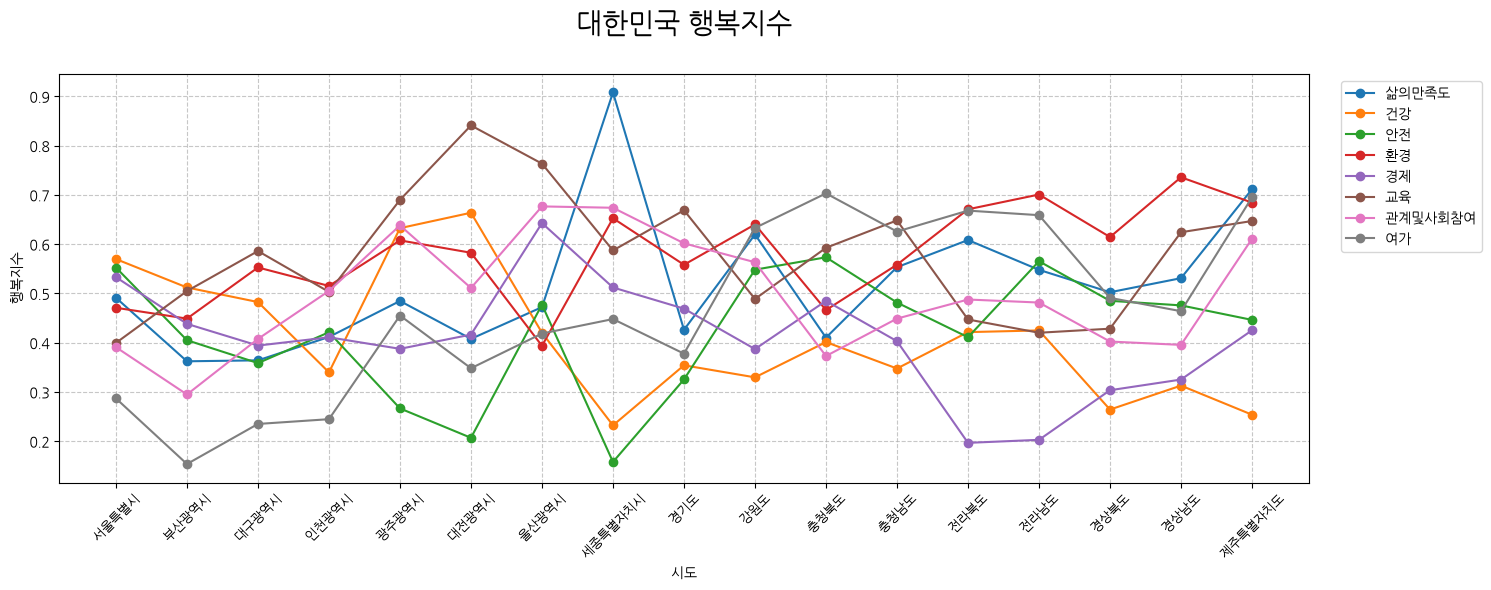

In [95]:
# 생성할 그래프의 가로, 세로 크기(단위는 인치)를 지정한다.
plt.figure(figsize=(15, 6))
# 0번 열인 '시도'를 제외하고, 실제 수치 데이터가 들어있는 시각화할 항목(1 ~ 8열)만 추출한다.
items = happy_merge.columns[1:9]
# print(items)

# x축으로 데이터프레임의 인덱스(0, 1, 2, ...)를 y축으로 현재 반복 중인 컬럼의 수치 데이터를 사용해서 꺾은선 그래프를 그린다.
for item in items:
    plt.plot(happy_merge.index, happy_merge[item], marker='o', label=item)

plt.xlabel('시도')
plt.ylabel('행복지수')
# xticks() 메소드는 x축의 눈금(ticks)의 위치와 그 위에 표시될 테스트를 세부적으로 설정한다.
# ticks=range(len(happy_merge)): 눈금을 표시할 위치에 데이터의 행 개수 만큼 생성한다.
# labels=happy_merge['시도']: x축 눈금 위치에 숫자가 아닌 '시도' 열의 지역 이름을 문자열로 매칭시켜 표한다.
plt.xticks(ticks=range(len(happy_merge)), labels=happy_merge['시도'], rotation=45, fontsize=9)
# pad=30: 제목과 그래프 상단 테두리 사이의 여백을 30포인트만큼 주어 제목이 그래프와 너무 붙지 않도록 한다.
plt.title('대한민국 행복지수', fontsize=20, pad=30)
# legend() 메소드는 어떤 선이 어떤 지표를 나타내는지 알려주는 범례를 표시한다.
# bbox_to_anchor: 범례를 그래프 영역 내부가 아니라 그래프 영역 오른쪽 바깥쪽에 위치시키도록 지정한다.
# loc는 범례를 그래프 영역 내부에 배치하는 방법을 지정한다. bbox_to_anchor 속성이 지정되면 무시된다.
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # 세로: upper, center, lower, 가로: left, right
plt.grid(True, linestyle='--', alpha=0.7)
# tight_layout() 메소드는 그래프의 여백을 알맞게 조절해서 x축의 지역 이름이나 오른쪽 바깥에 범례 등이 잘려나가는 현상을 방지한다.
plt.tight_layout()
plt.show()

happy_merge 데이터프레임에 담긴 여러 행복지수 데이터를 여러 개의 막대 그래프로 나누어 시각화 한다.

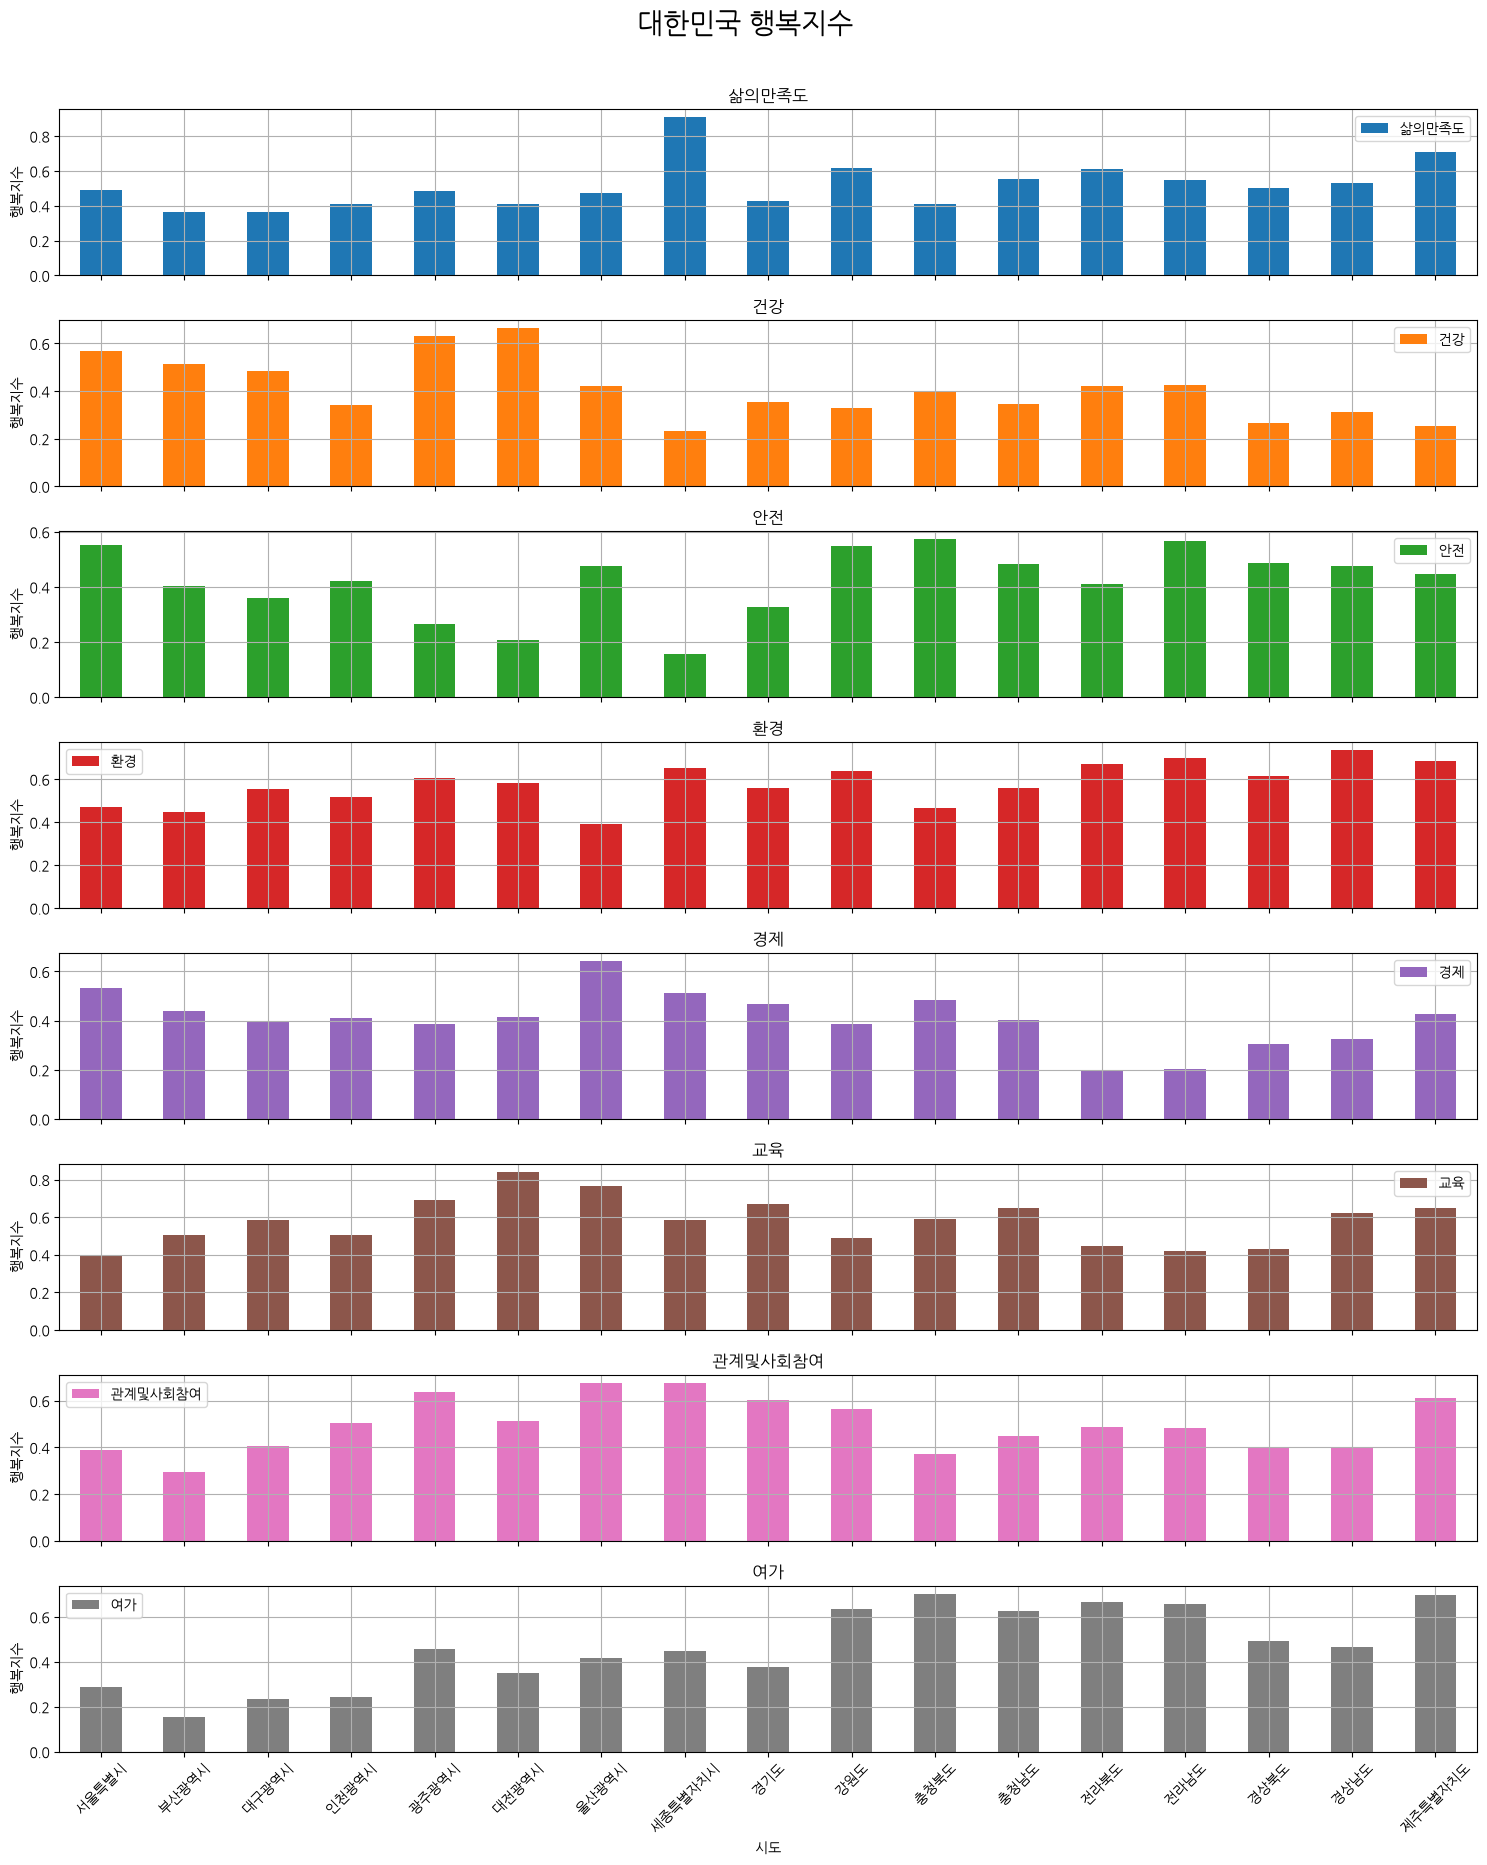

In [115]:
# set_index('시도'): happy_merge 데이터프레임에서 '시도' 열을 행의 인덱스로 지정해서 x축에 지역 이름들이 올 수 있도록 한다.
happy_merge.set_index('시도').iloc[:, 0:8].plot(
    kind='bar', xlabel='시도', ylabel='행복지수', figsize=(15, 20), grid=True, rot=45, subplots=True
)

# y=0.93: 그래프 전체 높이(0부터 1까지) 중 상단에서 93% 위치에 제목을 배치하도록 세로 위치를 조정한다.
plt.suptitle('대한민국 행복지수', fontsize=20, y=0.93)
# 여러 개의 subplot과 전체 제목이 겹치지 않도록 그래프 영역의 여백과 배치를 조정한다.
# rect=[left, bottom, right, top]는 그래프 영역에서 subplot들이 차지할 공간의 좌표를 비율로 지정한다.
# left = 0: 그래프 영역의 왼쪽 끝
# bottom = 0: 그래프 영역의 아래쪽 끝
# right = 1: 그래프 영역의 오른쪽 끝
# top = 0.92: 그래프 영역의 상단 92% 위치까지만 subplot을 배치하고, 나머지 위쪽 8%의 공간은 비워둔다.
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

happy_merge 데이터프레임에 담긴 여러 행복지수 데이터를 숫자 데이터 간 상관계수를 히트맵 형태로 시각화 한다.

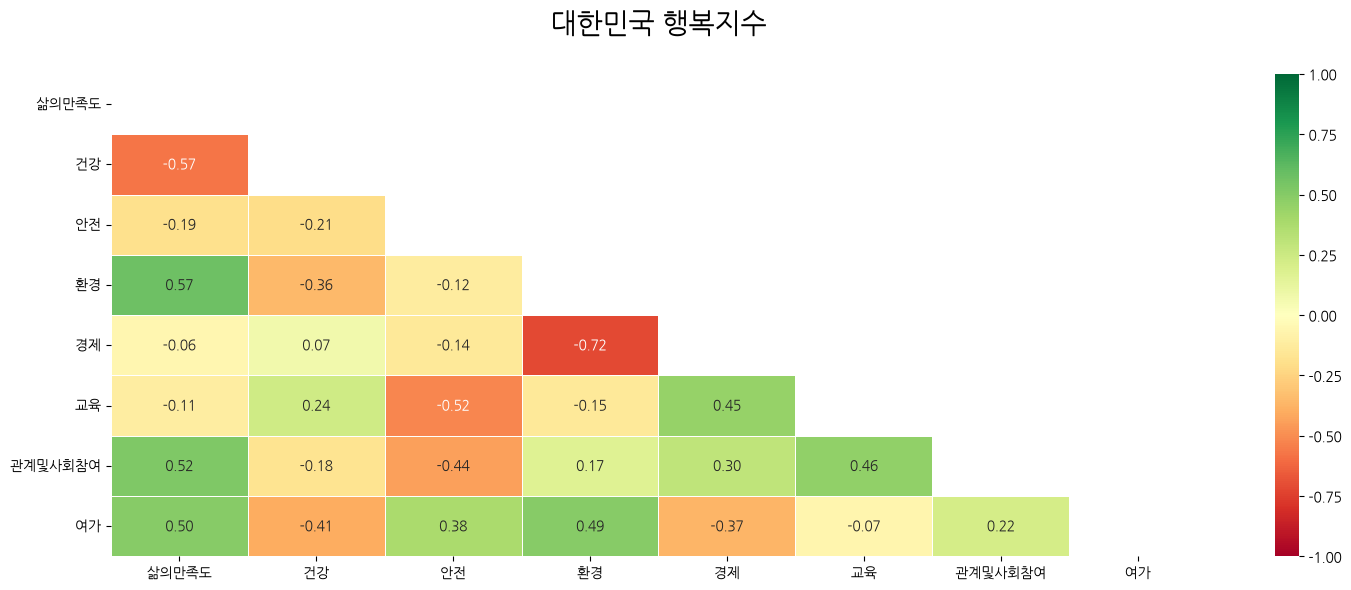

In [132]:
plt.figure(figsize=(15, 6))

corr_mat = happy_merge.corr(numeric_only=True) # 숫자 데이터만 추출해서 상관관계를 계산한다.
# 넘파이의 triu() 메소드는 행렬의 주 대각선을 기준으로 상단 삼각형 부분만 남기고 하단 삼각형 부분은 False(0)로 바꿔준다.
# 상관관계 히트맵은 주 대각선을 기준으로 위아래가 대칭이므로, 중복되는 절반을 숨기기 위해서 사용한다.
# np.ones_like(corr_mat, dtype=bool): corr_mat 행렬과 똑같은 shape을 가지는 행렬을 만들고 모든 값을 True로 채운다.
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

# 히트맵 시각화
sns.heatmap(
    data=corr_mat,   # 히트맵을 그릴 원본 데이터를 전달한다.
    mask=mask,       # mask를 적용해서 주 대각선을 기준으로 위쪽의 중복되는 영역은 그래프로 그려지지 않게한다.
    annot=True,      # 히트맵의 각 셀 한에 상관계수 숫자 값을 표시한다.
    fmt='.2f',       # 소수점 아래 둘째 자리까지만 보여준다.
    cmap='RdYlGn',   # 히트맵에 색상 팔레트를 지정한다.
    vmin=-1, vmax=1, # 상관계수는 항상 -1에서 1 사이의 값을 가지므로 색상 표션의 최소값과 최대값을 각각 -1과 1로 고정한다.
    linewidths=0.5   # 히트맵의 셀과 셀 사이에 테두리 선을 넣어, 칸들이 서로 구분되게 한다.
)

plt.title('대한민국 행복지수', fontsize=20, pad=30)
plt.tight_layout()
plt.show()